In [24]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)
print("Scikit-learn Version:", sklearn.__version__)
print("Matplotlib Version:", plt.matplotlib.__version__)

NumPy Version: 2.4.6
Pandas Version: 3.0.5
Scikit-learn Version: 1.9.0
Matplotlib Version: 3.11.0


In [25]:
# raw numbers in each series, one row per time step
data_x_train = pd.read_parquet("../data/X_train.parquet")
data_x_test = pd.read_parquet("../data/X_test.reduced.parquet")

# for the online part only — 0 or 1, did a break happen by now?
data_y_train = pd.read_parquet("../data/y_train.parquet")
data_y_test = pd.read_parquet("../data/y_test.reduced.parquet")

# one row per series — where the break happens, if it does
data_y_train_index = pd.read_parquet("../data/y_train_index.parquet")
data_y_test_index = pd.read_parquet("../data/y_test_index.reduced.parquet")

data_lst = [("X_train", data_x_train), ("X_test", data_x_test), ("y_train", data_y_train), ("y_test", data_y_test), ("y_train_index", data_y_train_index), ("y_test_index", data_y_test_index)]

data_x_train.head()

value  period
id time                  
0  0    -0.783992       1
   1    -0.414595       1
   2     1.674117       1
   3     1.575443       1
   4    -0.520342       1

In [26]:
for name, df in data_lst:
    banner = f"DataFrame: {name.upper()}"
    print(f"{'=' * len(banner)}\n{banner}\n{'=' * len(banner)}\n")

    # Check shape/structure: confirm id/time  multi index
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns}")
    print(f"Is MultiIndex: {df.index.nlevels > 1}")

    # Check null counts
    print(f"\nNull Counts:\n{df.isnull().sum()}\n")

    # Check series length distribution (aka how long is each time series)
    # Note: Each series is independent 
    print(f"Length Distribution: \n{df.groupby(level='id').size()}\n")



DataFrame: X_TRAIN

Shape: (35036464, 2)
Columns: Index(['value', 'period'], dtype='str')
Is MultiIndex: True

Null Counts:
value     0
period    0
dtype: int64

Length Distribution: 
id
0       1608
1       1373
2       3582
3       4759
4       4209
        ... 
9995    3916
9996    4180
9997    3153
9998    1700
9999    4489
Length: 10000, dtype: int64

DataFrame: X_TEST

Shape: (346019, 2)
Columns: Index(['value', 'period'], dtype='str')
Is MultiIndex: True

Null Counts:
value     0
period    0
dtype: int64

Length Distribution: 
id
10000    3629
10001    5670
10002    1646
10003    2935
10004    2882
         ... 
10095    4426
10096    2681
10097    3408
10098    5455
10099    4470
Length: 100, dtype: int64

DataFrame: Y_TRAIN

Shape: (5036517, 1)
Columns: Index(['target'], dtype='str')
Is MultiIndex: True

Null Counts:
target    0
dtype: int64

Length Distribution: 
id
0       416
1        34
2       837
3       433
4       909
       ... 
9995    278
9996    254
9997    804
999

In [27]:
data_x_train["value"].describe()

count    3.503646e+07
mean     3.849924e-03
std      7.154016e+00
min     -1.992598e+02
25%     -6.405943e-01
50%     -3.628966e-03
75%      6.365927e-01
max      1.578244e+04
Name: value, dtype: float64

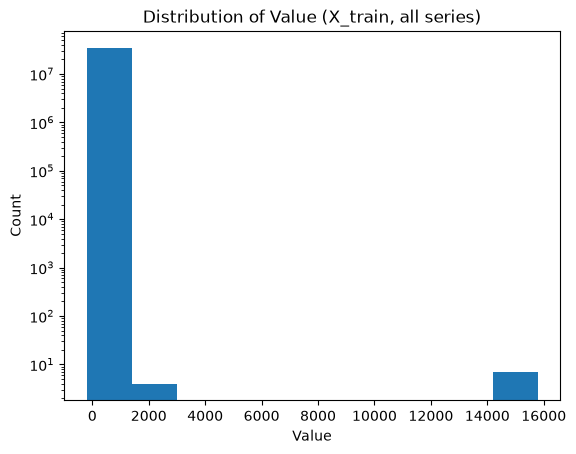

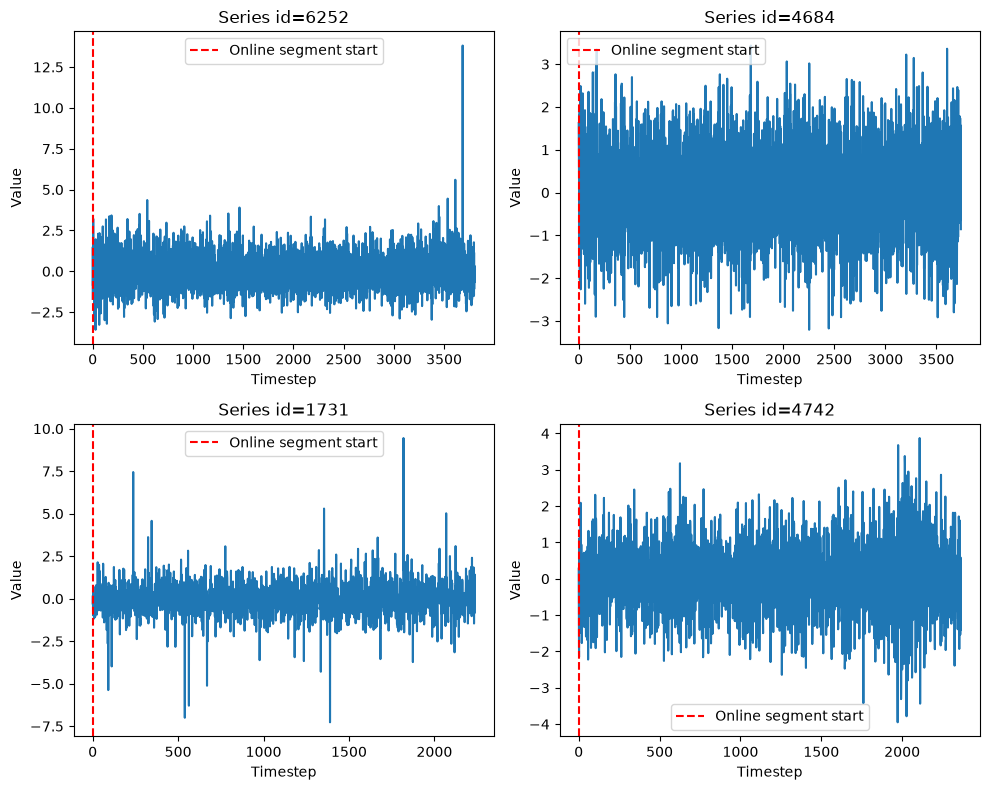

In [34]:
# Check for distribution of values in the training set
value = data_x_train["value"]
plt.hist(value)
plt.title('Distribution of Value (X_train, all series)')
plt.xlabel('Value')
plt.ylabel('Count')
plt.yscale('log')
plt.show()


# Plot random seroes from training set
np.random.seed(42)  # For reproducibility

random_ids = np.random.choice(data_x_train.index.get_level_values('id').unique(), size=4, replace=False)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, ax in zip(random_ids, axes.flat):
    serie = data_x_train.loc[i]  # Gets one series

    # Find where the online segment starts (first timestep where period == 1)
    online_start = serie[serie['period'] == 1].index.min()

    ax.plot(serie.index, serie['value'])
    ax.axvline(x=online_start, color='red', linestyle='--', label='Online segment start')
    ax.set_title(f'Series id={i}')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Value')
    ax.legend()

plt.tight_layout()
plt.show()

In [42]:
# Understand what tau is

# If tau = -1 -> No structural break
# If tau >= 0 Structural break occurs at timestep tau
tau = data_y_train_index["tau"]
tau_index = data_y_train_index["tau_index"] # Break position relative to the start of online segment

percent_no_break = ((tau == -1).sum()/len(tau))  * 100
print(f"Percentage of break vs no break:  {100 - percent_no_break} vs {percent_no_break}")

Percentage of break vs no break:  49.67 vs 50.33


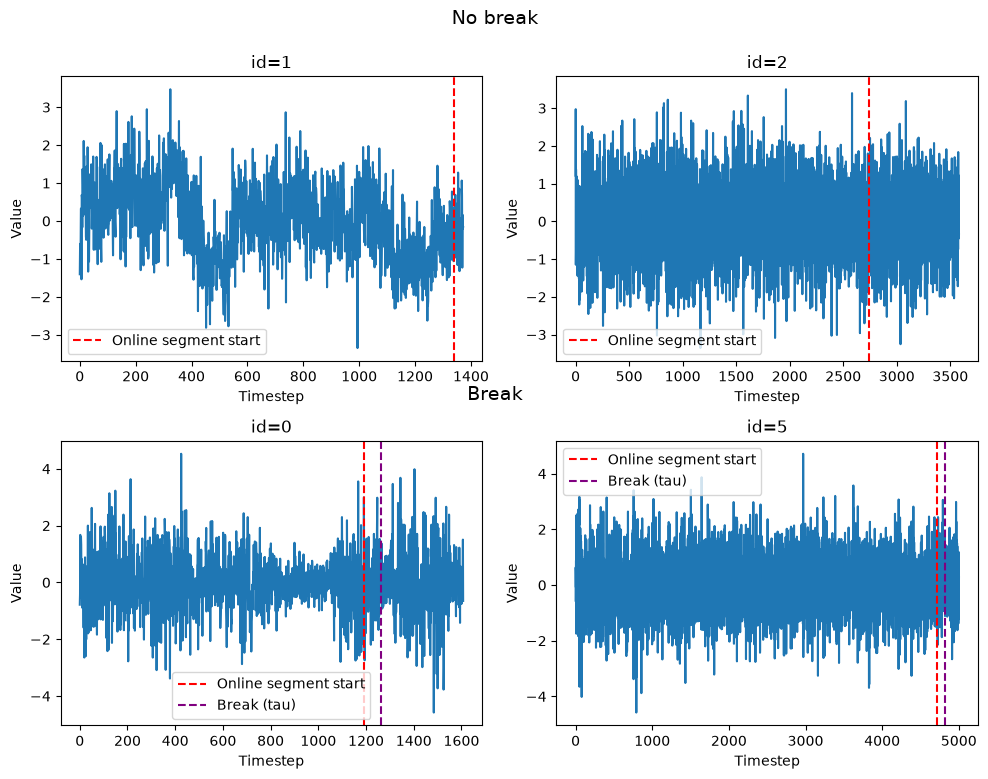

In [64]:
# Plot break vs no break
break_ids = data_y_train_index[data_y_train_index['tau'] != -1].index
no_break_ids = data_y_train_index[data_y_train_index['tau'] == -1].index

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Top row: no-break series
for ax, i in zip(axes[0], no_break_ids[:2]):
    serie = data_x_train.loc[i]
    online_start = serie[serie['period'] == 2].index.min()

    ax.plot(serie.index, serie['value'])
    ax.axvline(x=online_start, color='red', linestyle='--', label='Online segment start')
    ax.set_title(f'id={i}')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Value')
    ax.legend()

# Bottom row: break series
for ax, i in zip(axes[1], break_ids[:2]):
    serie = data_x_train.loc[i]
    online_start = serie[serie['period'] == 2].index.min()
    tau = data_y_train_index.loc[i, 'tau']

    ax.plot(serie.index, serie['value'])
    ax.axvline(x=online_start, color='red', linestyle='--', label='Online segment start')
    ax.axvline(x=tau, color='purple', linestyle='--', label='Break (tau)')
    ax.set_title(f'id={i}')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Value')
    ax.legend()

fig.text(0.5, 0.95, 'No break', ha='center', fontsize=14)
fig.text(0.5, 0.48, 'Break', ha='center', fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [ ]:
# Value distribution before and after break in online segment